# Machine Learning Regression Model

In [ ]:
???

Classification Model | Regression Model
-|-
![](src/pred_classification.png) | ![](src/pred_regression.png)

## [ ] Load the data

In [1]:
import pandas as pd

df = pd.read_excel('data/Microsoft_LinkedIn_Processed.xlsx', parse_dates=['Date'], index_col=0)
df

,Open,High,Low,Close,Volume,change_tomorrow,change_tomorrow_direction
Date,,,,,,,
2016-12-08,56.325228,56.582507,55.902560,56.058762,21220800,1.549143,UP
2016-12-09,56.214968,56.959234,56.169027,56.940857,27349400,0.321692,UP
2016-12-12,56.803028,57.244073,56.711145,57.124622,20198100,1.286112,UP
2016-12-13,57.427836,58.273172,57.188938,57.868881,35718900,-0.478622,DOWN
2016-12-14,57.887258,58.300739,57.455399,57.593227,30352700,-0.159789,DOWN
...,...,...,...,...,...,...,...
2023-03-09,255.820007,259.559998,251.580002,252.320007,26653400,-1.500467,DOWN
2023-03-10,251.080002,252.789993,247.600006,248.589996,28321800,2.099087,UP
2023-03-13,247.399994,257.910004,245.729996,253.919998,33339700,2.634307,UP


## Machine Learning Model

### Separate the data

1. Target: which variable do you want to predict?
2. Explanatory: which variables will you use to calculate the prediction?

In [2]:
target = df.change_tomorrow
explanatory = df[['Open','High','Low','Close','Volume']]

In [3]:
target

Date
2016-12-08    1.549143
2016-12-09    0.321692
2016-12-12    1.286112
2016-12-13   -0.478622
2016-12-14   -0.159789
                ...   
2023-03-09   -1.500467
2023-03-10    2.099087
2023-03-13    2.634307
2023-03-14    1.751806
2023-03-15    3.895731
Name: change_tomorrow, Length: 1576, dtype: float64

In [4]:
explanatory

,Open,High,Low,Close,Volume
Date,,,,,
2016-12-08,56.325228,56.582507,55.902560,56.058762,21220800
2016-12-09,56.214968,56.959234,56.169027,56.940857,27349400
2016-12-12,56.803028,57.244073,56.711145,57.124622,20198100
2016-12-13,57.427836,58.273172,57.188938,57.868881,35718900
2016-12-14,57.887258,58.300739,57.455399,57.593227,30352700
...,...,...,...,...,...
2023-03-09,255.820007,259.559998,251.580002,252.320007,26653400
2023-03-10,251.080002,252.789993,247.600006,248.589996,28321800
2023-03-13,247.399994,257.910004,245.729996,253.919998,33339700


### Compute the model

The following model will predict the **numerical increase** of the stock for the following day.

As the variable we predict is numerical, we talk about regression models. In the previous tutorial, we used a classification model since the variable we predicted was categorical (UP or DOWN).

In [5]:
from sklearn.tree import DecisionTreeRegressor

In [6]:
model_dt = DecisionTreeRegressor()

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(explanatory, target, test_size=0.2, random_state=42)

model_dt.fit(X=X_train, y=y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


## Visualize Model

[Text(0.9048682769499118, 0.9903846153846154, 'Volume <= 78979100.0\nsquared_error = 3.138\nsamples = 1260\nvalue = 0.112'),
 Text(0.8162127866316534, 0.9711538461538461, 'Volume <= 78451200.0\nsquared_error = 3.099\nsamples = 1248\nvalue = 0.127'),
 Text(0.8605405317907826, 0.9807692307692308, 'True  '),
 Text(0.8152164431344489, 0.9519230769230769, 'Open <= 262.304\nsquared_error = 3.047\nsamples = 1247\nvalue = 0.12'),
 Text(0.7293010506373578, 0.9326923076923077, 'Volume <= 46663750.0\nsquared_error = 3.01\nsamples = 1027\nvalue = 0.175'),
 Text(0.6806154546127584, 0.9134615384615384, 'Volume <= 39176800.0\nsquared_error = 2.429\nsamples = 945\nvalue = 0.218'),
 Text(0.6510958385182102, 0.8942307692307693, 'Open <= 260.32\nsquared_error = 2.113\nsamples = 886\nvalue = 0.162'),
 Text(0.6357799341942338, 0.875, 'Open <= 258.312\nsquared_error = 2.108\nsamples = 879\nvalue = 0.152'),
 Text(0.6126207017753155, 0.8557692307692307, 'Volume <= 38601750.0\nsquared_error = 2.08\nsamples = 8

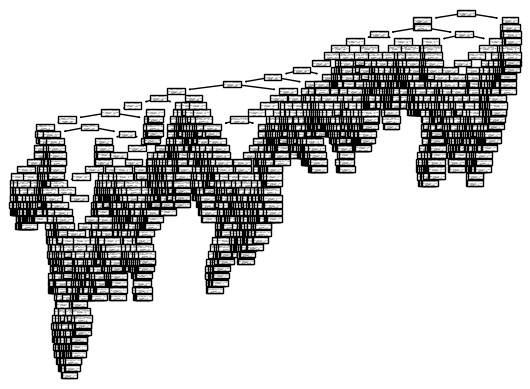

In [8]:
from sklearn.tree import plot_tree

plot_tree(decision_tree=model_dt, feature_names=model_dt.feature_names_in_)

### Calculate the predictions

In [9]:
y_pred = model_dt.predict(X_test)

### Evaluate the model: compare predictions with the reality

In [15]:
model_dt.score(X=explanatory, y=target)

0.5759574482840645

In [19]:
df_predictions = df[['change_tomorrow']].head(len(y_pred)).copy()

df_predictions['prediction'] = y_pred
df_predictions

,change_tomorrow,prediction
Date,,
2016-12-08,1.549143,-3.368444
2016-12-09,0.321692,0.006053
2016-12-12,1.286112,-3.024292
2016-12-13,-0.478622,1.138846
2016-12-14,-0.159789,-0.786916
...,...,...
2018-03-07,0.603618,-0.040428
2018-03-08,2.185622,-1.970946
2018-03-09,0.237697,0.187089


## [ ] How to interpret the error?

In [22]:
df_predictions['error'] = df_predictions['prediction'] - df_predictions['change_tomorrow']

In [23]:
df_predictions

,change_tomorrow,prediction,error
Date,,,
2016-12-08,1.549143,-3.368444,-4.917587
2016-12-09,0.321692,0.006053,-0.315639
2016-12-12,1.286112,-3.024292,-4.310405
2016-12-13,-0.478622,1.138846,1.617468
2016-12-14,-0.159789,-0.786916,-0.627127
...,...,...,...
2018-03-07,0.603618,-0.040428,-0.644047
2018-03-08,2.185622,-1.970946,-4.156567
2018-03-09,0.237697,0.187089,-0.050608


In [26]:
df_predictions['error'].sum().round(2)

np.float64(-33.0)

<Axes: >

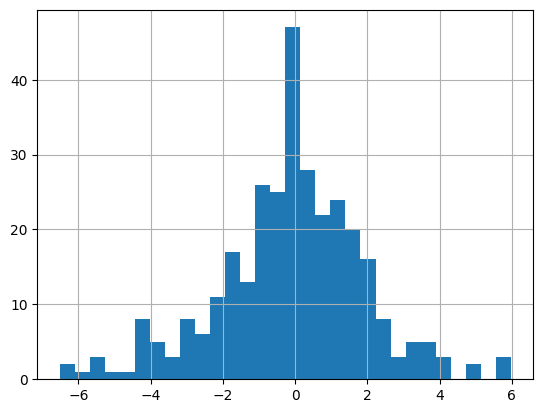

In [27]:
df_predictions['error'].hist(bins=30)

The Standard Deviation of the Error|The Normal Distribution
-|-
![](src/std.png) | ![](src/std_normal.png)

source: wikipedia

## Save the model into a file

- We'll write the numbers of the Decision Tree's mathematical equation into a file.

In [28]:
import pickle

In [29]:
with open('models/model_dt_regression.pkl', 'wb') as f:
    pickle.dump(model_dt, f)